# ISO 20414:2020 — Test 11: Maximum flow rates at an opening/exit

100 occupants in an 8 m x 5 m room with a 1 m exit centred on the 5 m wall (ISO 20414:2020 Table 12). Flow is emergent in the CollisionFreeSpeedModel; we verify the emergent exit flow stays at or below the MSC/Circ.1238 reference of 1.33 p/m/s that ISO Test 11 cites.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 30 May 2026, 20:48 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and run

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-11-max-flow.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())
result = run_scenario(scenario, seed=42)
df = result.trajectory_dataframe()

Scenario: /work/standards/iso/scenario_files/Iso-11-max-flow.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      240s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~100
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 100 agents


## Compute exit flow rate (agents crossing x = 0.3 per 1 s window)

In [5]:
EXIT_WIDTH_M = 1.0
THRESHOLD_PMS = 1.33
rows = []
for agent_id, sub in df.sort_values(['id', 'frame']).groupby('id'):
    crossed = sub[sub.x <= 0.3]
    if len(crossed):
        rows.append({'agent': int(agent_id), 'exit_time_s': crossed.iloc[0].frame / result.frame_rate})
exits_df = pd.DataFrame(rows).sort_values('exit_time_s').reset_index(drop=True)
window = 1.0
flow_rows = []
for t_end in np.arange(window, exits_df.exit_time_s.max() + window, window):
    count = ((exits_df.exit_time_s > t_end - window) & (exits_df.exit_time_s <= t_end)).sum()
    flow_rows.append({'t_end_s': t_end, 'flow_p_per_m_s': count / EXIT_WIDTH_M / window})
flow = pd.DataFrame(flow_rows)

## Plot flow vs time

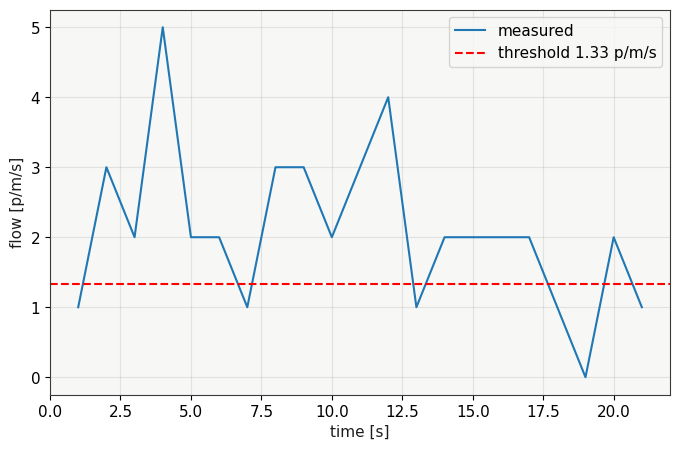

In [6]:
fig, ax = plt.subplots()
ax.plot(flow.t_end_s, flow.flow_p_per_m_s, label='measured')
ax.axhline(THRESHOLD_PMS, color='r', ls='--', label=f'threshold {THRESHOLD_PMS} p/m/s')
ax.set_xlabel('time [s]'); ax.set_ylabel('flow [p/m/s]'); ax.legend()
plt.show()

## Acceptance

ISO Test 11 cites the IMO MSC/Circ.1238 maximum specific flow of 1.33 p/m/s. The CollisionFreeSpeedModel has no door-flow limiter, so this is a **post-run comparison** (NIST Mode B), not an input cap: the emergent flow is reported against the reference rather than forced below it. The verification check is that the flow is well-defined and positive and that every occupant evacuates.

In [7]:
peak_flow = flow.flow_p_per_m_s.max()
mean_flow = flow.flow_p_per_m_s[flow.flow_p_per_m_s > 0].mean()
print(f'peak window flow = {peak_flow:.3f} p/m/s; mean active flow = {mean_flow:.3f} p/m/s; '
      f'reference = {THRESHOLD_PMS} p/m/s')
if mean_flow > THRESHOLD_PMS:
    print('NOTE: emergent CFSM flow exceeds the IMO reference (expected - no door throttle)')
print(f'evacuation time = {result.evacuation_time:.1f} s; agents remaining = {result.agents_remaining}')
assert np.isfinite(mean_flow) and mean_flow > 0, mean_flow
assert result.agents_remaining == 0, result.agents_remaining
result.cleanup()

peak window flow = 5.000 p/m/s; mean active flow = 2.200 p/m/s; reference = 1.33 p/m/s
NOTE: emergent CFSM flow exceeds the IMO reference (expected - no door throttle)
evacuation time = 23.4 s; agents remaining = 0
